# 10단계. 최종 모델, 점수 환산표, 위험 등급

- 용도: **종목별 위험 등급 표시**
- 모델: M3(`VolResidModel`, 트리 100개). 변동성 3개로 낙폭 수준을 잡고, 같은 날 종목 간 차이를 LightGBM으로 보정한다.
- 점수: D 방식. 예측 낙폭이 학습 기간 예측 분포에서 차지하는 백분위(0 ~ 100)다.
- 등급: 기본 5등급(20점 단위). 등급별 예상 낙폭과 실제 하락 비율은 교차검증 예측(표본 밖)으로 계산한다.
- 학습 구간(~2026-06-30) 데이터만 쓴다. 검증 구간은 11단계에서 1회 평가한다.
- 산출물: `outputs/model/`(모델, 환산표, 등급표, 메타데이터)

In [1]:
import json
import sys
import warnings
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import lightgbm
import sklearn

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.modeling import VolResidModel, expanding_folds, evaluate_predictions, TARGET, LEVEL_FEATURES, STOCK_FEATURES
from src.evaluate import daily_ic
from src.scoring import build_reference, to_score, to_grade, GRADE_EDGES, GRADE_LABELS
from src import plotting as P

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
P.setup()

LGB_PARAMS = {"n_estimators": 100}
ds = pd.read_parquet(ROOT / "data" / "cache" / "model_dataset.parquet")
folds = expanding_folds(ds)

# 1) 교차검증 예측(표본 밖): 등급별 성능 평가용
oof = []
for f in folds:
    tr, te = ds.iloc[f["train_idx"]], ds.iloc[f["test_idx"]]
    oof.append(te[["trade_date", "symbol", TARGET]].assign(pred=VolResidModel(lgb_params=LGB_PARAMS).fit(tr).predict(te), fold=f["fold"]))
oof = pd.concat(oof)
# 2) 최종 모델: 학습 구간 전체
final = VolResidModel(lgb_params=LGB_PARAMS).fit(ds)
ins = final.predict(ds)
e = evaluate_predictions(oof)
print(f"교차검증 예측 {len(oof):,}행 | 풀링 Spearman {oof[['pred', TARGET]].corr('spearman').iloc[0, 1]:.4f}, IC {e['IC']:.4f}, MAE {e['MAE']:.4f}")
print(f"최종 모델 학습 {len(ds):,}행 ({ds.trade_date.min().date()} ~ {ds.trade_date.max().date()})")

교차검증 예측 86,329행 | 풀링 Spearman 0.3213, IC 0.3393, MAE 0.0296
최종 모델 학습 107,880행 (2024-04-01 ~ 2026-06-23)


## 1. 점수 환산표

운영에서 쓰는 것은 최종 모델이므로, **최종 모델이 학습 구간 전체에 대해 낸 예측 분포**로 환산표를 만든다. 교차검증 예측 분포와 비교해 과적합으로 분포가 달라지지 않았는지 확인한다.

In [2]:
qs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
cmp_ = pd.DataFrame({"교차검증 예측": np.quantile(oof.pred, qs), "최종 모델(학습 구간 전체)": np.quantile(ins, qs)}, index=[f"{q:.0%}" for q in qs])
display(cmp_.round(4))
REF = build_reference(ins)
score_table = pd.DataFrame({"score": np.linspace(0, 100, len(REF)), "pred_mdd5": -REF})
show = score_table[score_table.score.isin([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100])]
show.round(4)

,교차검증 예측,최종 모델(학습 구간 전체)
1%,-0.0832,-0.0899
5%,-0.0695,-0.0715
10%,-0.0626,-0.0629
25%,-0.0513,-0.0512
50%,-0.0401,-0.0401
75%,-0.0313,-0.0317
90%,-0.0256,-0.0258
95%,-0.0227,-0.0228
99%,-0.0182,-0.0182


,score,pred_mdd5
0,0.0,-0.0116
100,10.0,-0.0258
200,20.0,-0.0300
300,30.0,-0.0333
400,40.0,-0.0366
500,50.0,-0.0401
600,60.0,-0.0440
700,70.0,-0.0486
800,80.0,-0.0542
900,90.0,-0.0629


## 2. 등급표 (교차검증 예측을 최종 환산표로 점수화)

In [3]:
oof["score"] = to_score(oof.pred, REF)
oof["grade"] = to_grade(oof.score)
def grade_stats(d, by="grade"):
    return d.groupby(by, observed=True).agg(
        비중=("score", lambda s: len(s) / len(d)), 예상_낙폭=("pred", "mean"), 실제_평균=(TARGET, "mean"),
        실제_중앙값=(TARGET, "median"), 실제_하위10=(TARGET, lambda s: s.quantile(0.10)),
        하락5_비율=(TARGET, lambda s: (s <= -0.05).mean()), 하락10_비율=(TARGET, lambda s: (s <= -0.10).mean()), n=("score", "size"))
gt = grade_stats(oof)
gt.insert(0, "점수", [f"{a} ~ {b}" for a, b in zip(GRADE_EDGES[:-1], GRADE_EDGES[1:])])
display(gt.round(4))
# 참고: 상위 구간 세분화
fine = oof.assign(band=pd.cut(oof.score, [80, 90, 95, 100.01], right=False))
display(grade_stats(fine.dropna(subset=["band"]), "band").round(4))

,점수,비중,예상_낙폭,실제_평균,실제_중앙값,실제_하위10,하락5_비율,하락10_비율,n
grade,,,,,,,,,
매우 낮음,0 ~ 20,0.2104,-0.0252,-0.0257,-0.0202,-0.0571,0.1365,0.0165,18163
낮음,20 ~ 40,0.1968,-0.0332,-0.0334,-0.0271,-0.0712,0.2261,0.0363,16986
보통,40 ~ 60,0.1921,-0.0402,-0.0396,-0.0324,-0.0855,0.3099,0.0636,16581
높음,60 ~ 80,0.1987,-0.0488,-0.0495,-0.0412,-0.1074,0.4165,0.1197,17156
매우 높음,80 ~ 100,0.2021,-0.0649,-0.0685,-0.0571,-0.1517,0.5547,0.2521,17443


,비중,예상_낙폭,실제_평균,실제_중앙값,실제_하위10,하락5_비율,하락10_비율,n
band,,,,,,,,
"[80.0, 90.0)",0.5157,-0.0582,-0.0596,-0.0500,-0.1297,0.5004,0.1944,8995
"[90.0, 95.0)",0.2829,-0.0667,-0.0686,-0.0579,-0.1526,0.5633,0.2557,4935
"[95.0, 100.01)",0.2014,-0.0796,-0.0913,-0.0808,-0.1960,0.6818,0.3945,3513


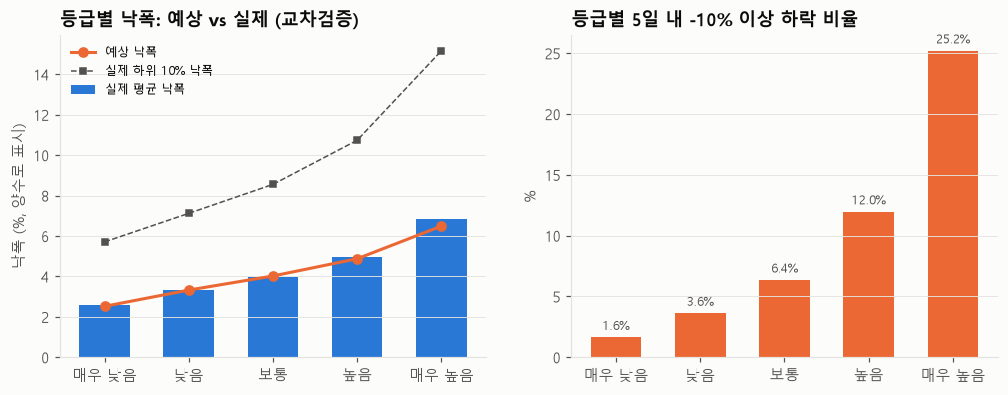

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(gt))
axes[0].bar(x, -gt["실제_평균"] * 100, color=P.SERIES[0], width=0.6, label="실제 평균 낙폭")
axes[0].plot(x, -gt["예상_낙폭"] * 100, color=P.SERIES[1], marker="o", lw=2, label="예상 낙폭")
axes[0].plot(x, -gt["실제_하위10"] * 100, color=P.TEXT_2, marker="s", ms=4, lw=1, ls="--", label="실제 하위 10% 낙폭")
axes[0].set_ylabel("낙폭 (%, 양수로 표시)")
axes[0].set_title("등급별 낙폭: 예상 vs 실제 (교차검증)")
axes[1].bar(x, gt["하락10_비율"] * 100, color=P.SERIES[1], width=0.6)
for i, v in enumerate(gt["하락10_비율"]):
    axes[1].text(i, v * 100 + 0.6, f"{v:.1%}", ha="center", fontsize=8, color=P.TEXT_2)
axes[1].set_ylabel("%")
axes[1].set_title("등급별 5일 내 -10% 이상 하락 비율")
for ax in axes:
    ax.set_xticks(x, GRADE_LABELS)
    ax.grid(axis="x", visible=False)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
P.save(fig, "10_grade_table")
plt.show()

## 3. 등급 안정성과 평활화

표시용 등급이 하루하루 자주 바뀌면 쓰기 어렵다. 최근 k일 예측의 평균으로 점수를 매기는 방식(과거 값만 사용하므로 누수 없음)을 비교한다.

In [5]:
def smooth(d, k):
    d = d.sort_values(["symbol", "trade_date"]).copy()
    d["pred_s"] = d.groupby("symbol")["pred"].transform(lambda s: s.rolling(k, min_periods=1).mean())
    return d

rows = []
for k in [1, 3, 5]:
    d = smooth(oof, k)
    d["score_s"] = to_score(d.pred_s, REF)
    d["g"] = to_grade(d.score_s).codes
    chg = d.groupby("symbol")["g"].diff()
    ic = daily_ic(d.assign(p=d.pred_s), ["p"], TARGET)["p"].mean()
    ev_top = (d.loc[d.g == 4, TARGET] <= -0.10).mean()
    rows.append({"평활화(일)": k, "풀링 Spearman": d[["pred_s", TARGET]].corr("spearman").iloc[0, 1], "IC": ic,
                 "하루 등급 변경 비율": (chg.fillna(0) != 0).mean(), "2등급 이상 변경": (chg.abs() >= 2).mean(),
                 "매우 높음 등급 -10% 비율": ev_top})
stab = pd.DataFrame(rows).set_index("평활화(일)")
stab.round(4)

,풀링 Spearman,IC,하루 등급 변경 비율,2등급 이상 변경,매우 높음 등급 -10% 비율
평활화(일),,,,,
1,0.3213,0.3393,0.1625,0.0039,0.2521
3,0.3158,0.3346,0.1058,0.0002,0.2498
5,0.3122,0.3319,0.0862,0.0000,0.2487


## 4. 시기별 등급 분포 (교차검증 예측)

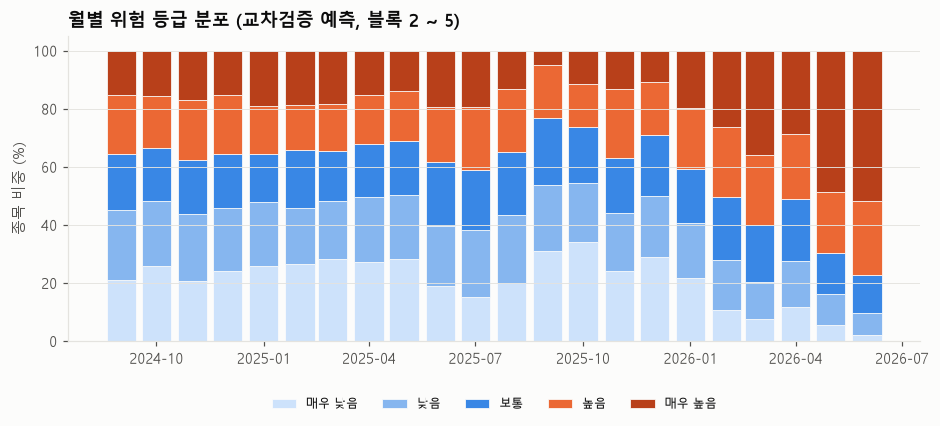

In [6]:
mon = oof.assign(ym=oof.trade_date.dt.to_period("M").dt.to_timestamp())
share = mon.groupby(["ym", "grade"], observed=True).size().unstack(fill_value=0)
share = share.div(share.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 3.6))
bottom = np.zeros(len(share))
colors = ["#cde2fb", "#86b6ef", "#3987e5", "#eb6834", "#b8401a"]
for g_, c in zip(GRADE_LABELS, colors):
    v = share.get(g_, pd.Series(0, index=share.index)).values
    ax.bar(share.index, v * 100, bottom=bottom * 100, width=25, color=c, label=g_, edgecolor=P.SURFACE, linewidth=0.5)
    bottom += v
ax.set_ylabel("종목 비중 (%)")
ax.set_title("월별 위험 등급 분포 (교차검증 예측, 블록 2 ~ 5)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.grid(axis="x", visible=False)
P.save(fig, "10_grade_share_monthly")
plt.show()

## 5. 저장

In [7]:
out = ROOT / "outputs" / "model"
out.mkdir(parents=True, exist_ok=True)
joblib.dump(final, out / "vol_resid_model.joblib")
score_table.to_csv(out / "score_reference.csv", index=False, encoding="utf-8-sig")
gt_out = gt.reset_index().rename(columns={"grade": "등급"})
gt_out.to_csv(out / "grade_table.csv", index=False, encoding="utf-8-sig")
meta = {
    "model": "VolResidModel (변동성 수준 Ridge + 횡단면 잔차 LightGBM)",
    "level_features": final.level_features, "cs_features": final.cs_features, "lgb_params": final.lgb_params,
    "target": "mdd_low = min(Low[t+1..t+5]) / Close[t] - 1 (KRX 정규장)",
    "train_period": [str(ds.trade_date.min().date()), str(ds.trade_date.max().date())], "train_rows": int(len(ds)),
    "score": "D 방식: 최종 모델의 학습 구간 예측 분포 백분위 (score_reference.csv, 1001개 분위)",
    "grades": dict(zip(GRADE_LABELS, [f"[{a}, {b})" for a, b in zip(GRADE_EDGES[:-1], GRADE_EDGES[1:])])),
    "cv": {"pooled_spearman": float(oof[["pred", TARGET]].corr("spearman").iloc[0, 1]), "IC": float(e["IC"]), "MAE": float(e["MAE"])},
    "versions": {"lightgbm": lightgbm.__version__, "sklearn": sklearn.__version__, "pandas": pd.__version__},
    "created": str(date.today()),
}
(out / "model_meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
oof.to_parquet(ROOT / "data" / "cache" / "oof_final.parquet", index=False)
# 저장한 모델을 다시 읽어 같은 예측이 나오는지 확인
chk = joblib.load(out / "vol_resid_model.joblib").predict(ds)
assert np.allclose(chk, ins)
print("저장:", sorted(p.name for p in out.iterdir()))

저장: ['grade_table.csv', 'model_meta.json', 'score_reference.csv', 'vol_resid_model.joblib']


## 6. 요약

- **최종 모델**: M3(트리 100개). 학습 구간 전체 107,880행으로 학습했다. 교차검증 성능은 풀링 Spearman 0.321, IC 0.339, MAE 0.0296이다.
- **점수 환산표**: 최종 모델의 학습 구간 예측 분포로 만들었다. 교차검증 예측 분포와 1 ~ 99% 구간이 거의 같다. 1% 꼬리만 조금 더 넓다(-9.0% vs -8.3%).
  - 기준점: 50점 = 예상 낙폭 -4.0%, 80점 = -5.4%, 90점 = -6.3%, 95점 = -7.2%, 99점 = -9.0%
- **등급표 (교차검증 예측, 표본 밖)**

| 등급 | 점수 | 예상 낙폭 | 실제 평균 | 실제 하위 10% | -10% 이상 하락 |
|---|---|---:|---:|---:|---:|
| 매우 낮음 | 0 ~ 20 | -2.5% | -2.6% | -5.7% | 1.7% |
| 낮음 | 20 ~ 40 | -3.3% | -3.3% | -7.1% | 3.6% |
| 보통 | 40 ~ 60 | -4.0% | -4.0% | -8.6% | 6.4% |
| 높음 | 60 ~ 80 | -4.9% | -5.0% | -10.7% | 12.0% |
| 매우 높음 | 80 ~ 100 | -6.5% | -6.9% | -15.2% | 25.2% |

  - 등급이 올라갈수록 모든 지표가 단조롭게 나빠지고, 예상 낙폭과 실제 평균의 차이는 0.4%p 이내다.
  - '매우 높음' 안에서도 95점 이상은 -10% 이상 하락 비율이 39%(80 ~ 90점은 19%)로 더 위험하다. 필요하면 6등급으로 나눌 수 있다.
- **등급 안정성**
  - 매일 새로 점수를 매기면 하루에 16%의 종목이 등급을 바꾼다(2등급 이상 변경 0.4%).
  - **최근 3일 예측 평균**으로 점수를 매기면 변경 비율이 11%로 줄고, 2등급 이상 변경은 사실상 0이다. 성능 손실은 작다(풀링 Spearman 0.321 → 0.316).
- **시기별 분포**
  - 평온한 시기에는 등급이 고르게 나뉜다.
  - 2026년 상반기처럼 변동성이 큰 시기에는 '매우 높음' 비중이 50%까지 올라간다. 과거 대비 수준을 나타내는 D 방식의 의도된 동작이다.
- **저장**: `outputs/model/`
  - `vol_resid_model.joblib`(다시 읽어 같은 예측이 나오는지 확인했다)
  - `score_reference.csv`(점수 1001단계 ↔ 예상 낙폭)
  - `grade_table.csv`
  - `model_meta.json`